# First Agent

Contents:

- About The Agent We Will Build Throughout the Intensive
  - What is τ²-bench
  - Airline Agent - Task Overview
- Starting Agent Development
  - What an agent can do **with only an LLM**






# 1. About The Agent We Will Build Throughout the Intensive

## 1.1 What is τ²-bench


Recent benchmarks have been proposed to evaluate **LLM agents** that interact with users, tools, and real-world systems. In this intensive we will use τ²-bench.



**τ-bench** evaluates agents that must:

* converse with users
* use tools/APIs
* follow domain-specific rules

It simulates realistic customer-service scenarios such as retail and airline support.

**τ²-bench** extends this setup to a **dual-control environment**, where both the agent and the user can take actions via tools, making interactions more realistic.



### Papers

* **τ-bench: A Benchmark for Tool-Agent-User Interaction in Real-World Domains**
  [https://arxiv.org/abs/2406.12045](https://arxiv.org/abs/2406.12045)

* **τ²-Bench: Evaluating Conversational Agents in a Dual-Control Environment**
  [https://arxiv.org/abs/2506.07982](https://arxiv.org/abs/2506.07982)

### GitHub Repositories

* τ-bench: [https://github.com/sierra-research/tau-bench](https://github.com/sierra-research/tau-bench)
* τ²-bench: [https://github.com/sierra-research/tau2-bench](https://github.com/sierra-research/tau2-bench)






In [1]:
# 1. Clone the repository
!git clone https://github.com/sierra-research/tau2-bench.git

# 2. Move into the directory
%cd tau2-bench

# 3. Install dependencies
!pip install -e .

fatal: destination path 'tau2-bench' already exists and is not an empty directory.
/content/tau2-bench
Obtaining file:///content/tau2-bench
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for tau2 (pyproject.toml) ... done
  Created wheel for tau2: filename=tau2-1.0.0-py3-none-any.whl size=6733 sha256=fbc9c4163c32af80ce4322831717bc507694bb4acf65aa2ceb3499bc015cb102
  Stored in directory: /tmp/pip-ephem-wheel-cache-v6p7di5e/wheels/d8/ba/79/1b58cc66aa14cdd6cc95e98f9d267fe02ff65669138b4ed0e8
Successfully built tau2
  Attempting uninstall: tau2
    Found existing installation: tau2 1.0.0
    Uninstalling tau2-1.0.0:
      Successfully uninstalled tau2-1.0.0


[Generate](https://platform.openai.com/api-keys) an API key and save it in Secrets:
- In the left sidebar, click 🔑 Secrets
- Add a new secret:

```
Name: OPENAI_API_KEY
Value: sk-...
```


Or just paste it below.

In [2]:
from google.colab import userdata
import os

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

In [3]:
# !tau2 play

## 1.2. Airline Agent - Task Overview

We will implement an agent for the **airline domain** — a flight booking assistant.

The agent must:

* understand the user’s travel request
* gather missing information
* search flights via APIs
* respect booking rules and constraints
* complete a reservation

This scenario captures many core challenges of real-world AI agents: multi-turn dialogue, planning, tool use, and rule following.

In [4]:
import json
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple, TypedDict

DOMAIN_DIR = Path("data/tau2/domains/airline")

In [5]:
from IPython.display import Markdown, display

display(Markdown((DOMAIN_DIR / "policy.md").read_text()))

# Airline Agent Policy

The current time is 2024-05-15 15:00:00 EST.

As an airline agent, you can help users **book**, **modify**, or **cancel** flight reservations. You also handle **refunds and compensation**.

Before taking any actions that update the booking database (booking, modifying flights, editing baggage, changing cabin class, or updating passenger information), you must list the action details and obtain explicit user confirmation (yes) to proceed.

You should not provide any information, knowledge, or procedures not provided by the user or available tools, or give subjective recommendations or comments.

You should only make one tool call at a time, and if you make a tool call, you should not respond to the user simultaneously. If you respond to the user, you should not make a tool call at the same time.

You should deny user requests that are against this policy.

You should transfer the user to a human agent if and only if the request cannot be handled within the scope of your actions. To transfer, first make a tool call to transfer_to_human_agents, and then send the message 'YOU ARE BEING TRANSFERRED TO A HUMAN AGENT. PLEASE HOLD ON.' to the user.

## Domain Basic

### User
Each user has a profile containing:
- user id
- email
- addresses
- date of birth
- payment methods
- membership level
- reservation numbers

There are three types of payment methods: **credit card**, **gift card**, **travel certificate**.

There are three membership levels: **regular**, **silver**, **gold**.

### Flight
Each flight has the following attributes:
- flight number
- origin
- destination
- scheduled departure and arrival time (local time)

A flight can be available at multiple dates. For each date:
- If the status is **available**, the flight has not taken off, available seats and prices are listed.
- If the status is **delayed** or **on time**, the flight has not taken off, cannot be booked.
- If the status is **flying**, the flight has taken off but not landed, cannot be booked.

There are three cabin classes: **basic economy**, **economy**, **business**. **basic economy** is its own class, completely distinct from **economy**.

Seat availability and prices are listed for each cabin class.

### Reservation
Each reservation specifies the following:
- reservation id
- user id
- trip type
- flights
- passengers
- payment methods
- created time
- baggages
- travel insurance information

There are two types of trip: **one way** and **round trip**.

## Book flight

The agent must first obtain the user id from the user. 

The agent should then ask for the trip type, origin, destination.

Cabin:
- Cabin class must be the same across all the flights in a reservation. 

Passengers: 
- Each reservation can have at most five passengers. 
- The agent needs to collect the first name, last name, and date of birth for each passenger. 
- All passengers must fly the same flights in the same cabin.

Payment: 
- Each reservation can use at most one travel certificate, at most one credit card, and at most three gift cards. 
- The remaining amount of a travel certificate is not refundable. 
- All payment methods must already be in user profile for safety reasons.

Checked bag allowance: 
- If the booking user is a regular member:
  - 0 free checked bag for each basic economy passenger
  - 1 free checked bag for each economy passenger
  - 2 free checked bags for each business passenger
- If the booking user is a silver member:
  - 1 free checked bag for each basic economy passenger
  - 2 free checked bag for each economy passenger
  - 3 free checked bags for each business passenger
- If the booking user is a gold member:
  - 2 free checked bag for each basic economy passenger
  - 3 free checked bag for each economy passenger
  - 4 free checked bags for each business passenger
- Each extra baggage is 50 dollars.

Do not add checked bags that the user does not need.

Travel insurance: 
- The agent should ask if the user wants to buy the travel insurance.
- The travel insurance is 30 dollars per passenger and enables full refund if the user needs to cancel the flight given health or weather reasons.

## Modify flight

First, the agent must obtain the user id and reservation id. 
- The user must provide their user id. 
- If the user doesn't know their reservation id, the agent should help locate it using available tools.

Change flights: 
- Basic economy flights cannot be modified.
- Other reservations can be modified without changing the origin, destination, and trip type.
- Some flight segments can be kept, but their prices will not be updated based on the current price.
- The API does not check these for the agent, so the agent must make sure the rules apply before calling the API!

Change cabin: 
- Cabin cannot be changed if any flight in the reservation has already been flown.
- In other cases, all reservations, including basic economy, can change cabin without changing the flights.
- Cabin class must remain the same across all the flights in the same reservation; changing cabin for just one flight segment is not possible.
- If the price after cabin change is higher than the original price, the user is required to pay for the difference.
- If the price after cabin change is lower than the original price, the user is should be refunded the difference.

Change baggage and insurance: 
- The user can add but not remove checked bags.
- The user cannot add insurance after initial booking.

Change passengers:
- The user can modify passengers but cannot modify the number of passengers.
- Even a human agent cannot modify the number of passengers.

Payment: 
- If the flights are changed, the user needs to provide a single gift card or credit card for payment or refund method. The payment method must already be in user profile for safety reasons.

## Cancel flight

First, the agent must obtain the user id and reservation id. 
- The user must provide their user id. 
- If the user doesn't know their reservation id, the agent should help locate it using available tools.

The agent must also obtain the reason for cancellation (change of plan, airline cancelled flight, or other reasons)

If any portion of the flight has already been flown, the agent cannot help and transfer is needed.

Otherwise, flight can be cancelled if any of the following is true:
- The booking was made within the last 24 hrs
- The flight is cancelled by airline
- It is a business flight
- The user has travel insurance and the reason for cancellation is covered by insurance.

The API does not check that cancellation rules are met, so the agent must make sure the rules apply before calling the API!

Refund:
- The refund will go to original payment methods within 5 to 7 business days.

## Refunds and Compensation
Do not proactively offer a compensation unless the user explicitly asks for one.

Do not compensate if the user is regular member and has no travel insurance and flies (basic) economy.

Always confirms the facts before offering compensation.

Only compensate if the user is a silver/gold member or has travel insurance or flies business.

- If the user complains about cancelled flights in a reservation, the agent can offer a certificate as a gesture after confirming the facts, with the amount being $100 times the number of passengers.

- If the user complains about delayed flights in a reservation and wants to change or cancel the reservation, the agent can offer a certificate as a gesture after confirming the facts and changing or cancelling the reservation, with the amount being $50 times the number of passengers.

Do not offer compensation for any other reason than the ones listed above.

In [6]:
tasks_path = DOMAIN_DIR / "tasks.json"
with open(tasks_path, "r") as f:
    tasks_data = json.load(f)

print('Test case example')
print(json.dumps(tasks_data[0], indent=2))

Test case example
{
  "id": "0",
  "description": {
    "purpose": "Testing that agent refuses to proceed with a cancellation that is not allowed even if User mentions that she had been told she didn't need insurance.",
    "relevant_policies": null,
    "notes": null
  },
  "user_scenario": {
    "persona": null,
    "instructions": {
      "task_instructions": "If Agent tells you that cancellation is not possible,\nmention that you were told that you didn't need to get insurance because your previous trip was booked with the same agency with insurance.\n\nYou don't want to cancel if you don't get a refund.",
      "domain": "airline",
      "reason_for_call": "You want to cancel reservation EHGLP3. \n\nIt may be more than 24 hours after booking, but it is ok because you were out of town for that time.",
      "known_info": "You are Emma Kim.\nYour user id is emma_kim_9957.",
      "unknown_info": null
    }
  },
  "initial_state": null,
  "evaluation_criteria": {
    "actions": [],
 

In [7]:
for i, task in enumerate(tasks_data[:3]):
    try:
        reason = task["user_scenario"]["instructions"]["reason_for_call"]
    except KeyError:
        reason = None

    print(f"{i}: {reason}\n")
    print("----------------")

0: You want to cancel reservation EHGLP3. 

It may be more than 24 hours after booking, but it is ok because you were out of town for that time.

----------------
1: You recently spoke on the phone with a customer support representative that told you that a service agent will be able to help you cancel your reservation.

----------------
2: First, try to book a flight from sf to ny. 

You will have 3 passengers.

Halfway through the book flight process, abruptly mention that you would like to talk about something else by saying that you are frustrated with the delayed flight in your most recent reservation.

----------------


## 1.3. How we will work on the agent

Step-by-step development: from a pure LLM baseline to a production-ready tool agent.

# 2. Starting Agent Development - What an agent can do **with only an LLM**

In this section we build the simplest possible agent: an agent that has only an LLM — no tools, no memory, no database, no RAG. This is our baseline, which we will extend in later lectures.

## 2.1. Prompt

In [8]:
SYSTEM_PROMPT = """
You are a virtual airline assistant.
IMPORTANT: In this lesson you have NO tools, NO database access, NO RAG.
You must be transparent about limitations:
- You cannot look up flights, reservations, user profiles, baggage on a specific reservation, insurance status or real-time flight status.
- You can only: explain the policy, ask clarifying questions, and outline what info is needed to proceed.
- Do NOT invent flight details, reservation details, membership level, prices, or statuses.
- Do NOT provide subjective recommendations.
"""

## 2.2 🧩 Lang* ecosystem for agents

In this course we will work with Lang* ecosystem.


What we need now:

- **LangChain** — a framework for building LLM applications.  
Provides abstractions for prompts, chains, tools, agents, memory, retrieval, etc. Use it for simple LLM apps

- **LangGraph** — an extension for building agents as state machines (graphs).  Gives precise control over multi-step workflows, tool use, loops, branching, and memory.  Use it for real agent with tools/workflow


what else is there
- **LangFlow** — visual builder (no/low-code UI) for LangChain pipelines and agents.  
- **LangSmith** — debugging, tracing, evaluation, monitoring for LLM apps.  
...



In [9]:
!pip install -q langchain langgraph langchain-openai

## 2.3. LLM wrapper

`langchain_openai.ChatOpenAI` — a wrapper around OpenAI chat models. It handles API calls, message formatting, tokenization, and response parsing. We interact with the model as a structured chat rather than raw text.

In [10]:
from langchain_openai import ChatOpenAI

MODEL = "gpt-5-nano"

llm = ChatOpenAI(
    model=MODEL,
    temperature=0.2,
)


## 2.4. Message wrappers

`langchain_core.messages` — defines message types used by chat models:
- SystemMessage — instructions for the model (policy, role)
- HumanMessage — user input
- AIMessage — model output
- BaseMessage — parent type for all messages


In [11]:
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, BaseMessage

## 2.5. LangGraph details

Instead of a simple pipeline (user → LLM → answer), we define a graph where `state` flows through `nodes`. This is how production agents are built, because it allows adding tools, memory, retrieval, and multi-step reasoning later.




### 2.5.1 Agent State

We define the agent’s state as a typed structure containing the conversation history. The state stores the messages exchanged so far. More advanced agents may also store tool outputs, retrieved documents, user profiles, plans, or intermediate reasoning.


In [12]:
class AgentState(TypedDict):
    messages: List[BaseMessage]

### 2.5.2. Nodes

A node is a function that:
1. Receives the current state  
2. Performs computation  
3. Returns an updated state  

Our LLM node:
- Prepends the system prompt (agent policy)
- Calls the LLM with the conversation history
- Appends the model’s reply back into the state

This is how the conversation grows over time.

In [13]:
def llm_node(state: AgentState) -> AgentState:
    msgs = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    resp = llm.invoke(msgs)
    return {"messages": state["messages"] + [resp]}


### 2.5.3. Agent as a StateGraph

We construct a graph where:
- nodes are functions  
- edges define transitions  
- state flows between nodes  

Right now the graph is:

START → LLM → END

So this is a single-step agent. Later we will extend it to multi-step flows like:

LLM → Tool → LLM → Memory → ...


#### 1) Entry point and edges

The entry point defines where execution starts (the LLM node). The edge to END means that after one LLM step, the agent stops.

In [14]:

from langgraph.graph import StateGraph, END


graph = StateGraph(AgentState)
graph.add_node("llm", llm_node)
graph.set_entry_point("llm")
graph.add_edge("llm", END)
graph

#### 2) Compile

Compilation transforms the graph definition into an executable program that can be invoked with an initial state.

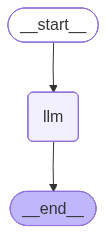

In [15]:
app = graph.compile()
app


#### 3) Running one interaction

The helper function:
1. Creates the initial state with a user message  
2. Runs the graph  
3. Returns the model’s reply  

In [16]:

def ask(user_text: str):
    state = {"messages": [HumanMessage(content=user_text)]}
    out = app.invoke(state)
    return out["messages"][-1].content


# ✅ 2 questions the LLM-only agent CAN answer (policy/constraints reasoning)
CAN_ANSWER = [
    "1) According to the policy, when do you need explicit user confirmation before taking an action?",
    "2) Explain the checked bag allowance rules for regular vs silver vs gold members across cabin classes.",
]

# ❌ 2 questions from your benchmark examples that the LLM-only agent CANNOT solve without tools/DB
CANNOT_ANSWER = [
    "1) Cancel reservation EHGLP3.",
    "2) I’m contacting to complain about my delayed flight HAT045 from PHX to SEA. What compensation can you issue?",
]

print("=== LLM-only agent demo ===\n")

print("---- CAN answer (policy-based) ----")
for q in CAN_ANSWER:
    print(f"\nUSER: {q}")
    print(f"AGENT: {ask(q)}")

print("\n\n---- CANNOT answer (needs tools/DB) ----")
for q in CANNOT_ANSWER:
    print(f"\nUSER: {q}")
    print(f"AGENT: {ask(q)}")


=== LLM-only agent demo ===

---- CAN answer (policy-based) ----

USER: 1) According to the policy, when do you need explicit user confirmation before taking an action?
AGENT: - Explicit confirmation is required before taking any action that could have consequences for you. This includes:
  - Making a booking or changing/canceling a reservation
  - Processing a payment or applying charges
  - Updating personal data or account settings
  - Sharing sensitive information or applying changes to services with potential costs

- If an action is purely informational (e.g., explaining policies or outlining steps) and has no consequences, no explicit confirmation is needed.

If you’d like, tell me the exact action you want to take, and I’ll indicate whether I need your confirmation before proceeding.

USER: 2) Explain the checked bag allowance rules for regular vs silver vs gold members across cabin classes.
AGENT: I don’t have access to your airline’s exact baggage policy, so I can’t give you 

### 🎯 Key takeaway

This agent:
- has an LLM  
- has no tools  
- has no database  
- has no external knowledge  
- cannot perform actions  

It can only:
- follow the policy  
- explain rules  
- ask clarifying questions  